In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

@njit
def rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out

@njit
def rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.sqrt(1 + (b * r)**2)
    return out

@njit
def d2rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**(3/2)
            out[i, j] = b**2 / denom
    return out

@njit
def rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / np.sqrt(1 + (b * r)**2)
    return out

@njit
def d2rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**(5/2)
            out[i, j] = b**2 * (3 * (b * r)**2 - 1) / denom
    return out

@njit
def rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / (1 + (b * r)**2)
    return out

@njit
def d2rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**3
            out[i, j] = 2 * b**2 * (3 * (b * r)**2 - 1) / denom
    return out



# -------- Wendland C^2:  φ(s) = (1 - s)^4 (4s + 1),  s = b |x-c| ∈ [0,1] --------
@njit
def rbf_wendland_c2(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = (t**4) * (4.0*s + 1.0)
            else:
                out[i, j] = 0.0
    return out

@njit
def d2rbf_wendland_c2(x, c, b):

    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = b2 * (-20.0) * (t**2) * (1.0 - 4.0*s)
            else:
                out[i, j] = 0.0
    return out

# -------- Wendland C^4:  phi(s) = (1 - s)^6 (35 s^2 + 18 s + 3), s = b |x-c| in [0,1] --------
@njit
def rbf_wendland_c4(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                poly = 35.0*s*s + 18.0*s + 3.0
                out[i, j] = (t**6) * poly
            else:
                out[i, j] = 0.0
    return out

@njit
def d2rbf_wendland_c4(x, c, b):
    # phi''_C4(s) = 28 * (1 - s)^4 * (70 s^2 - 8 s - 2), for 0 <= s < 1; then multiply by b^2
    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = b2 * 28.0 * (t**4) * (70.0*s*s - 8.0*s - 2.0)
            else:
                out[i, j] = 0.0
    return out



def solver_rbf(N, rbf_func, d2rbf_func, tau=1e-15, beta=3e5):
    zeta = 2
    T = 4.0
    M = zeta * N
    c_val = np.pi/(T * np.sqrt(2 * np.log(1 + tau**(-2))))
    b = c_val * (N ** (0.9))

    a1, a2 = -1.0, -1.5

    x = np.linspace(0, 1, M)
    lower_a = 0.0
    upper_b = 1.0
    L = 0.5 * (upper_b -  lower_a)
    q = 0.5 * (lower_a  + upper_b) 
    centers = np.linspace(q - T * L, q + T * L, N)
    dx = x[1] - x[0]

    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    rhs = f(x)

    Phi_raw = rbf_func(x, centers, b)
    Phi = Phi_raw / np.sqrt(N)

    D2Phi = d2rbf_func(x, centers, b) / np.sqrt(N)
    A1 = D2Phi.T @ D2Phi * dx
    r_vec = -D2Phi.T @ rhs * dx

    x_bdry = np.array([0.0, 1.0])
    Phi_bdry = rbf_func(x_bdry, centers, b) / np.sqrt(N)
    g_bdry = u_true(x_bdry)

    A3 = np.sqrt(beta / 2) * Phi_bdry
    r3 = np.sqrt(beta / 2) * g_bdry

    A_total = A1 + A3.T @ A3
    b_total = r_vec + A3.T @ r3

    U, S, VT = svd(A_total)
    S_inv = np.where(S > tau * np.max(S), 1/S, 0)
    w_tau = VT.T @ (S_inv * (U.T @ b_total))

    u_hat_tau = Phi @ w_tau
    u_exact = u_true(x)
    return np.linalg.norm(u_hat_tau - u_exact) / np.linalg.norm(u_exact) ** 2






# Plot
#fig, axs = plt.subplots(1, 1, figsize=(16, 8))

# Left: RBF type comparison
#markers = ['o', 's', 'd', '^']
#for i, (name, errs) in enumerate(errors_rbf.items()):
#    axs[0].plot(N_values, errs,'-',label=name, linewidth=4.5, marker=markers[i])
#axs[0].set_xticks(N_values)
#axs[0].set_yscale('log')
#axs[0].set_title(r'Radial Basis Function Comparison', fontsize=20)
#axs[0].set_xlabel(r'$N$: number of basis functions', fontsize=18)
#axs[0].set_ylabel(r'Relative $L^2$ Error', fontsize=18)
#axs[0].tick_params(labelsize=16)
#axs[0].grid(True)
#axs[0].legend(fontsize=14)

# Right: Tau sensitivity for Gaussian
#for i, (tau, errs) in enumerate(errors_tau.items()):
#    axs[1].plot(N_values, errs,'-',label=fr"$\tau = {tau:.0e}$", linewidth=4.5, marker=markers[i % len(markers)])
#axs[1].set_xticks(N_values)
#axs[1].set_yscale('log')
#axs[1].set_title(r'Thresholding Value $\tau, \phi_{RBF} \coloneq Gaussian$', fontsize=20)
#axs[1].set_xlabel(r'$N$: number of basis functions', fontsize=18)
#axs[1].set_ylabel(r'Relative $L^2$ Error', fontsize=18)
#axs[1].tick_params(labelsize=16)
#axs[1].grid(True)
#axs[1].legend(fontsize=14)

#plt.tight_layout()
#plt.savefig('fig3_poisson.png')


In [2]:
# Benchmarking RBF types
N_values = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

rbf_types = {
    'Gaussian': (rbf_gaussian, d2rbf_gaussian),
    'MQ': (rbf_mq, d2rbf_mq),
    'IMQ': (rbf_imq, d2rbf_imq),
    'InvQuad': (rbf_invquad, d2rbf_invquad),
    'Wendland C2': (rbf_wendland_c2, d2rbf_wendland_c2),
    'Wendland C4': (rbf_wendland_c4, d2rbf_wendland_c4),
}


errors_rbf = {name: [] for name in rbf_types}

for N in N_values:
    for name, (func, d2func) in rbf_types.items():
        err = solver_rbf(N, func, d2func)
        errors_rbf[name].append(err)

# Benchmarking tau for Gaussian RBF
tau_values = [1e-6, 1e-10, 1e-12, 1e-15]
errors_tau = {tau: [] for tau in tau_values}

for N in N_values:
    for tau in tau_values:
        err = solver_rbf(N, rbf_gaussian, d2rbf_gaussian, tau=tau)
        errors_tau[tau].append(err)


/tmp/ipykernel_3061637/1703124769.py:183: RuntimeWarning: divide by zero encountered in divide
  S_inv = np.where(S > tau * np.max(S), 1/S, 0)


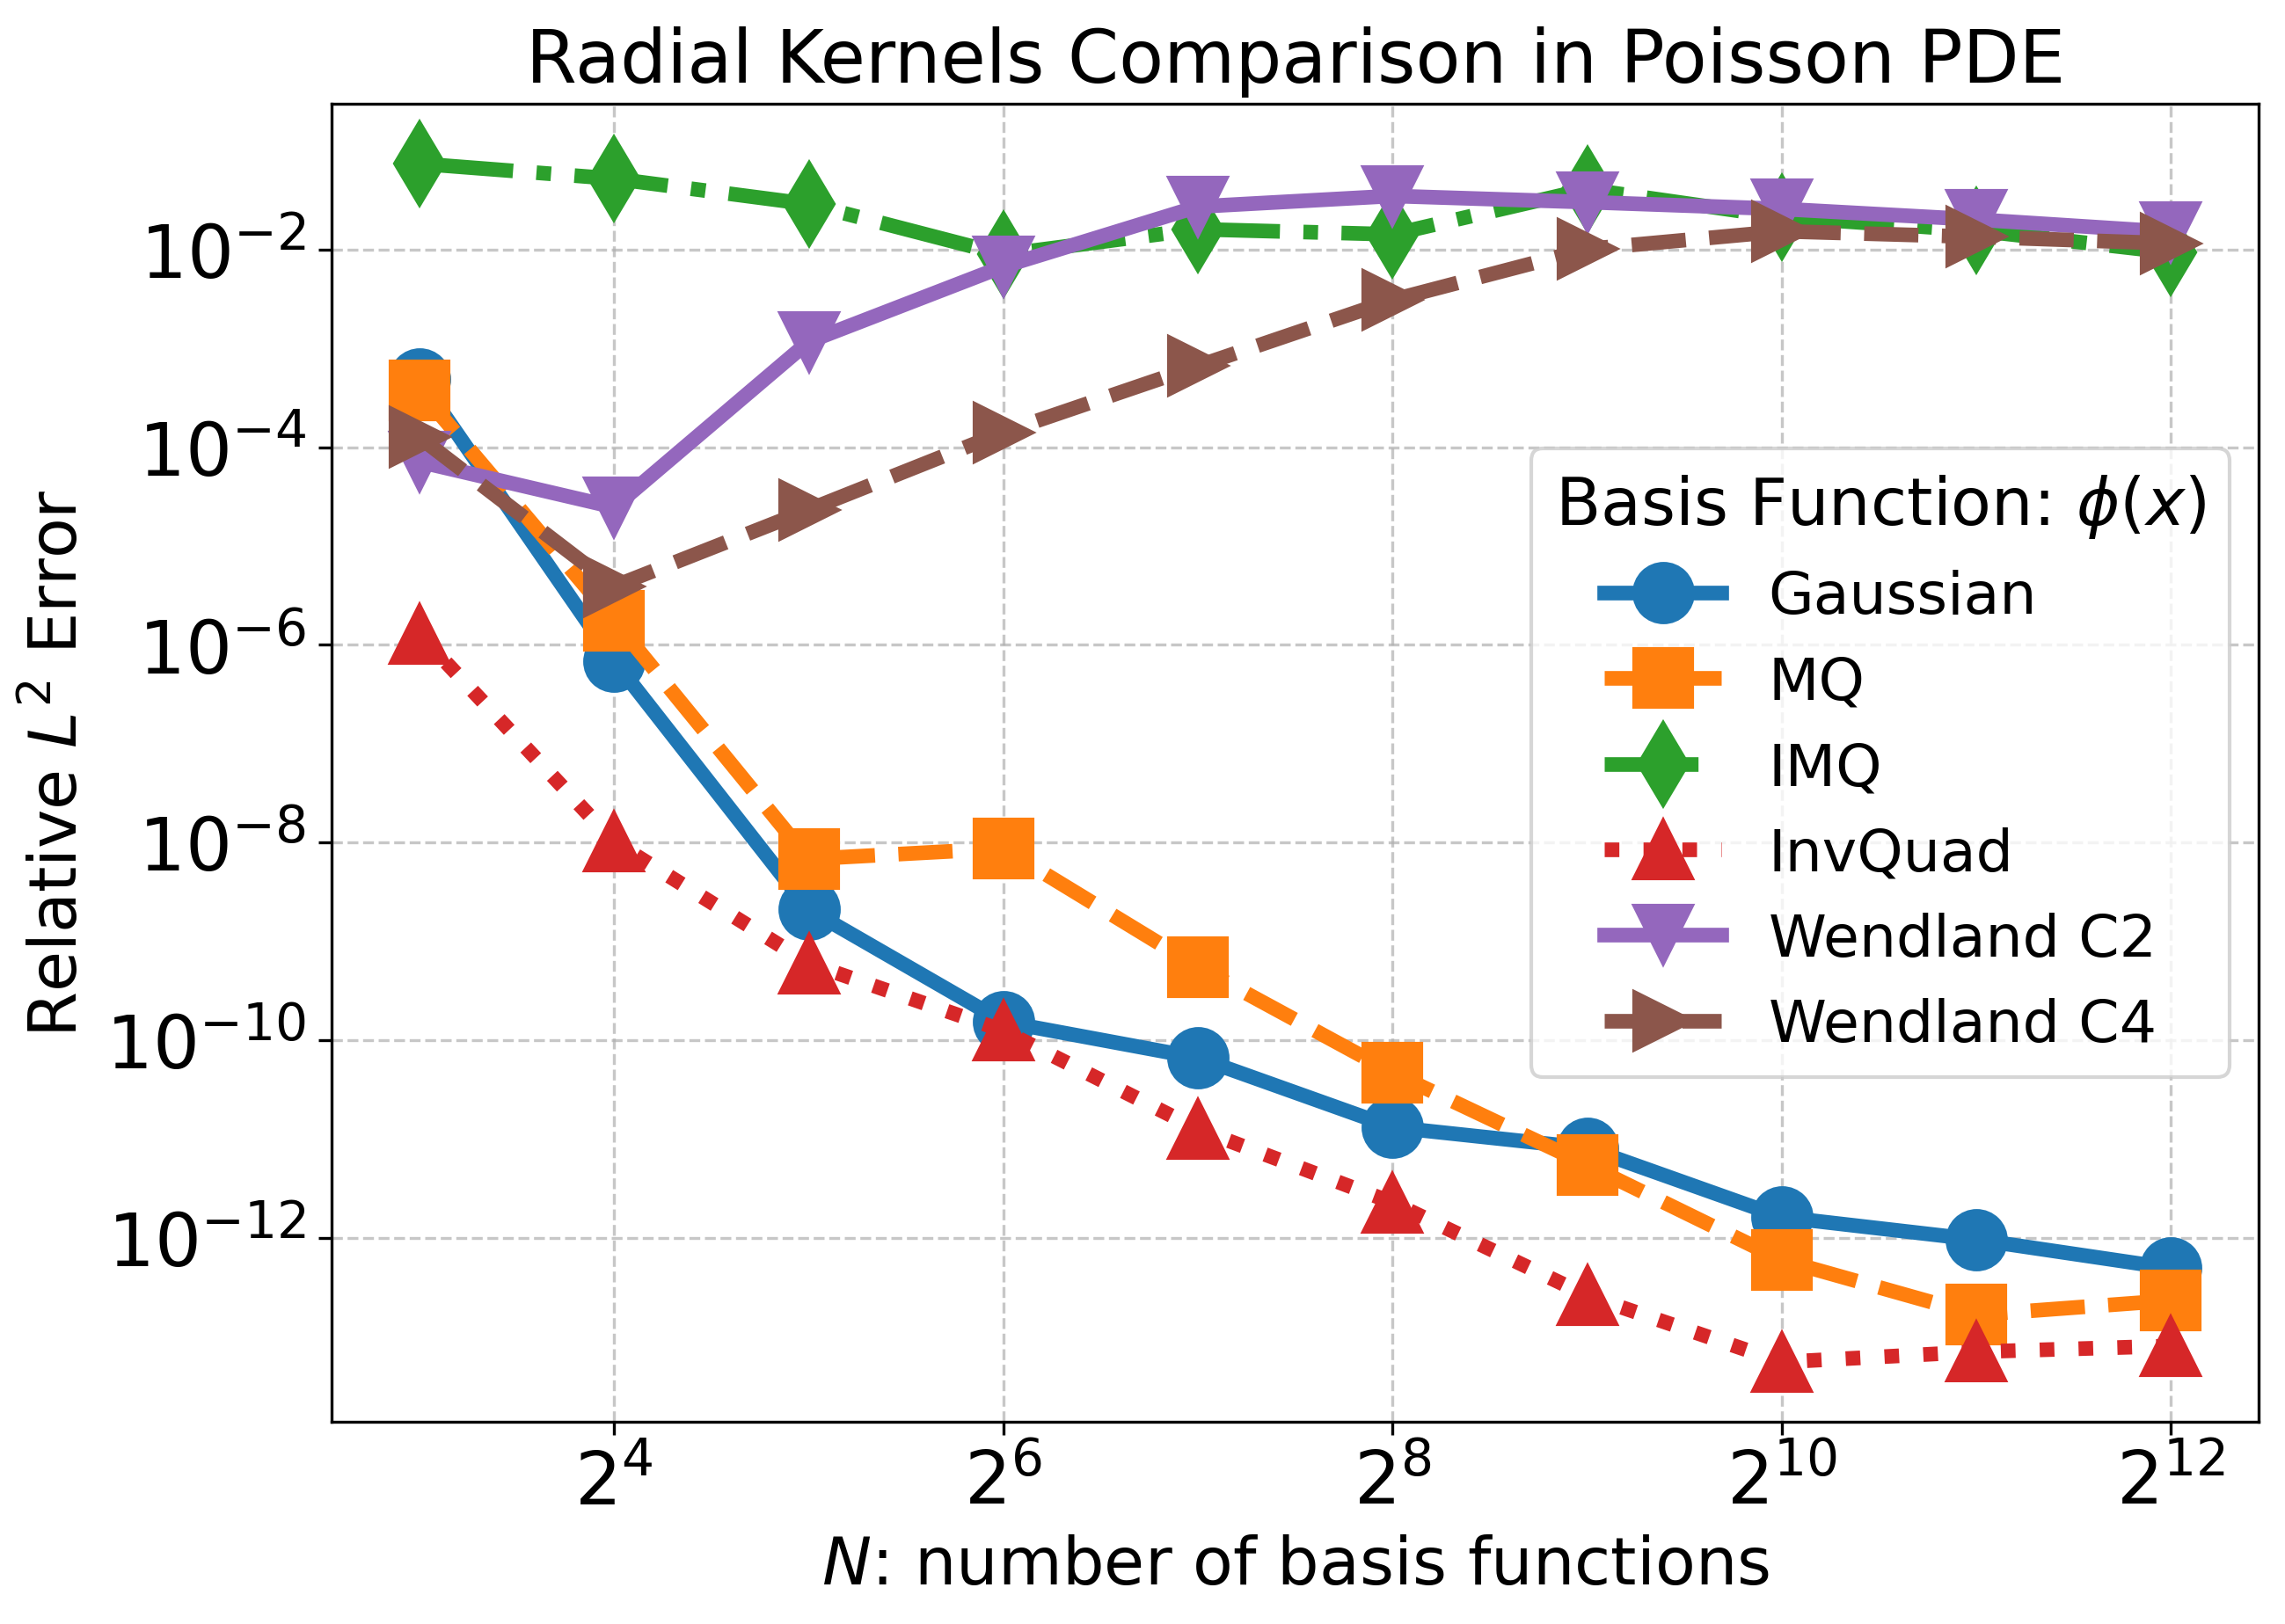

In [14]:
from itertools import cycle
# --- Single plot: RBF type comparison ---

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 16,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(9, 6.5), dpi = 300)

markers_cycle = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyles = ['-', '--', '-.', ':']  # will cycle if there are >4 series

for i, (name, errs) in enumerate(errors_rbf.items()):
    ax.plot(
        N_values,
        errs,
        linestyle=linestyles[i % len(linestyles)],
        marker=next(markers_cycle),
        linewidth=4.0,
        label=name
    )


ax.set_xscale('log', base = 2)
ax.set_yscale('log')
ax.set_title(r'Radial Kernels Comparison in Poisson PDE')
ax.set_xlabel(r'$N$: number of basis functions')
ax.set_ylabel(r'Relative $L^2$ Error')
ax.tick_params(labelsize=20)
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(title = f'Basis Function: $\phi(x)$',fontsize=16, title_fontsize = 18)

plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig3_poisson.png', dpi=300, bbox_inches='tight')


# Benchmark $\beta$ in Poisson PDE

# T = 2.0

In [4]:
# ---- helper for c(T, tau)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# ---- settings
tau = 1e-15
T = 2.0
c_shape = float(c_from_T(T, tau))   # your code uses eps = c_shape * N
N_list = [256, 512, 1024, 2048]
beta_values = np.logspace(1, 10, num=12)  # 1e1 ... 1e10 (10 points)

# ---- storage: dict of {N: [errors vs beta]}
errors_vs_beta = {N: [] for N in N_list}

# ---- run sweep
for beta in beta_values:
    for N in N_list:
        rel_L2_sq = solver_rbf( N = N, rbf_func = rbf_gaussian, d2rbf_func = d2rbf_gaussian, tau=tau, beta=beta)
        errors_vs_beta[N].append(rel_L2_sq)

# ---- pretty print a table
header = ["beta"] + [f"N={N}" for N in N_list]
print("{:>12s}  ".format(header[0]) + "  ".join(f"{h:>12s}" for h in header[1:]))
for i, beta in enumerate(beta_values):
    row = [f"{beta:12.3e}"] + [f"{errors_vs_beta[N][i]:12.3e}" for N in N_list]
    print("  ".join(row))

        beta         N=256         N=512        N=1024        N=2048
   1.000e+01     2.132e-12     2.485e-12     1.595e-12     8.466e-13
   6.579e+01     2.023e-12     2.466e-12     1.612e-12     8.500e-13
   4.329e+02     2.810e-12     2.464e-12     1.594e-12     8.763e-13
   2.848e+03     1.958e-12     2.448e-12     1.584e-12     7.238e-13
   1.874e+04     1.166e-11     2.408e-12     1.626e-12     7.864e-13
   1.233e+05     1.268e-11     2.536e-12     1.665e-12     4.998e-13
   8.111e+05     7.290e-11     8.373e-12     2.152e-12     4.929e-13
   5.337e+06     7.538e-11     2.935e-11     5.821e-12     1.123e-12
   3.511e+07     4.245e-10     8.472e-11     1.428e-11     3.572e-12
   2.310e+08     4.582e-10     2.589e-10     3.185e-11     9.172e-12
   1.520e+09     2.540e-09     7.781e-10     1.060e-10     2.377e-11
   1.000e+10     1.272e-08     2.241e-09     2.327e-10     5.659e-11


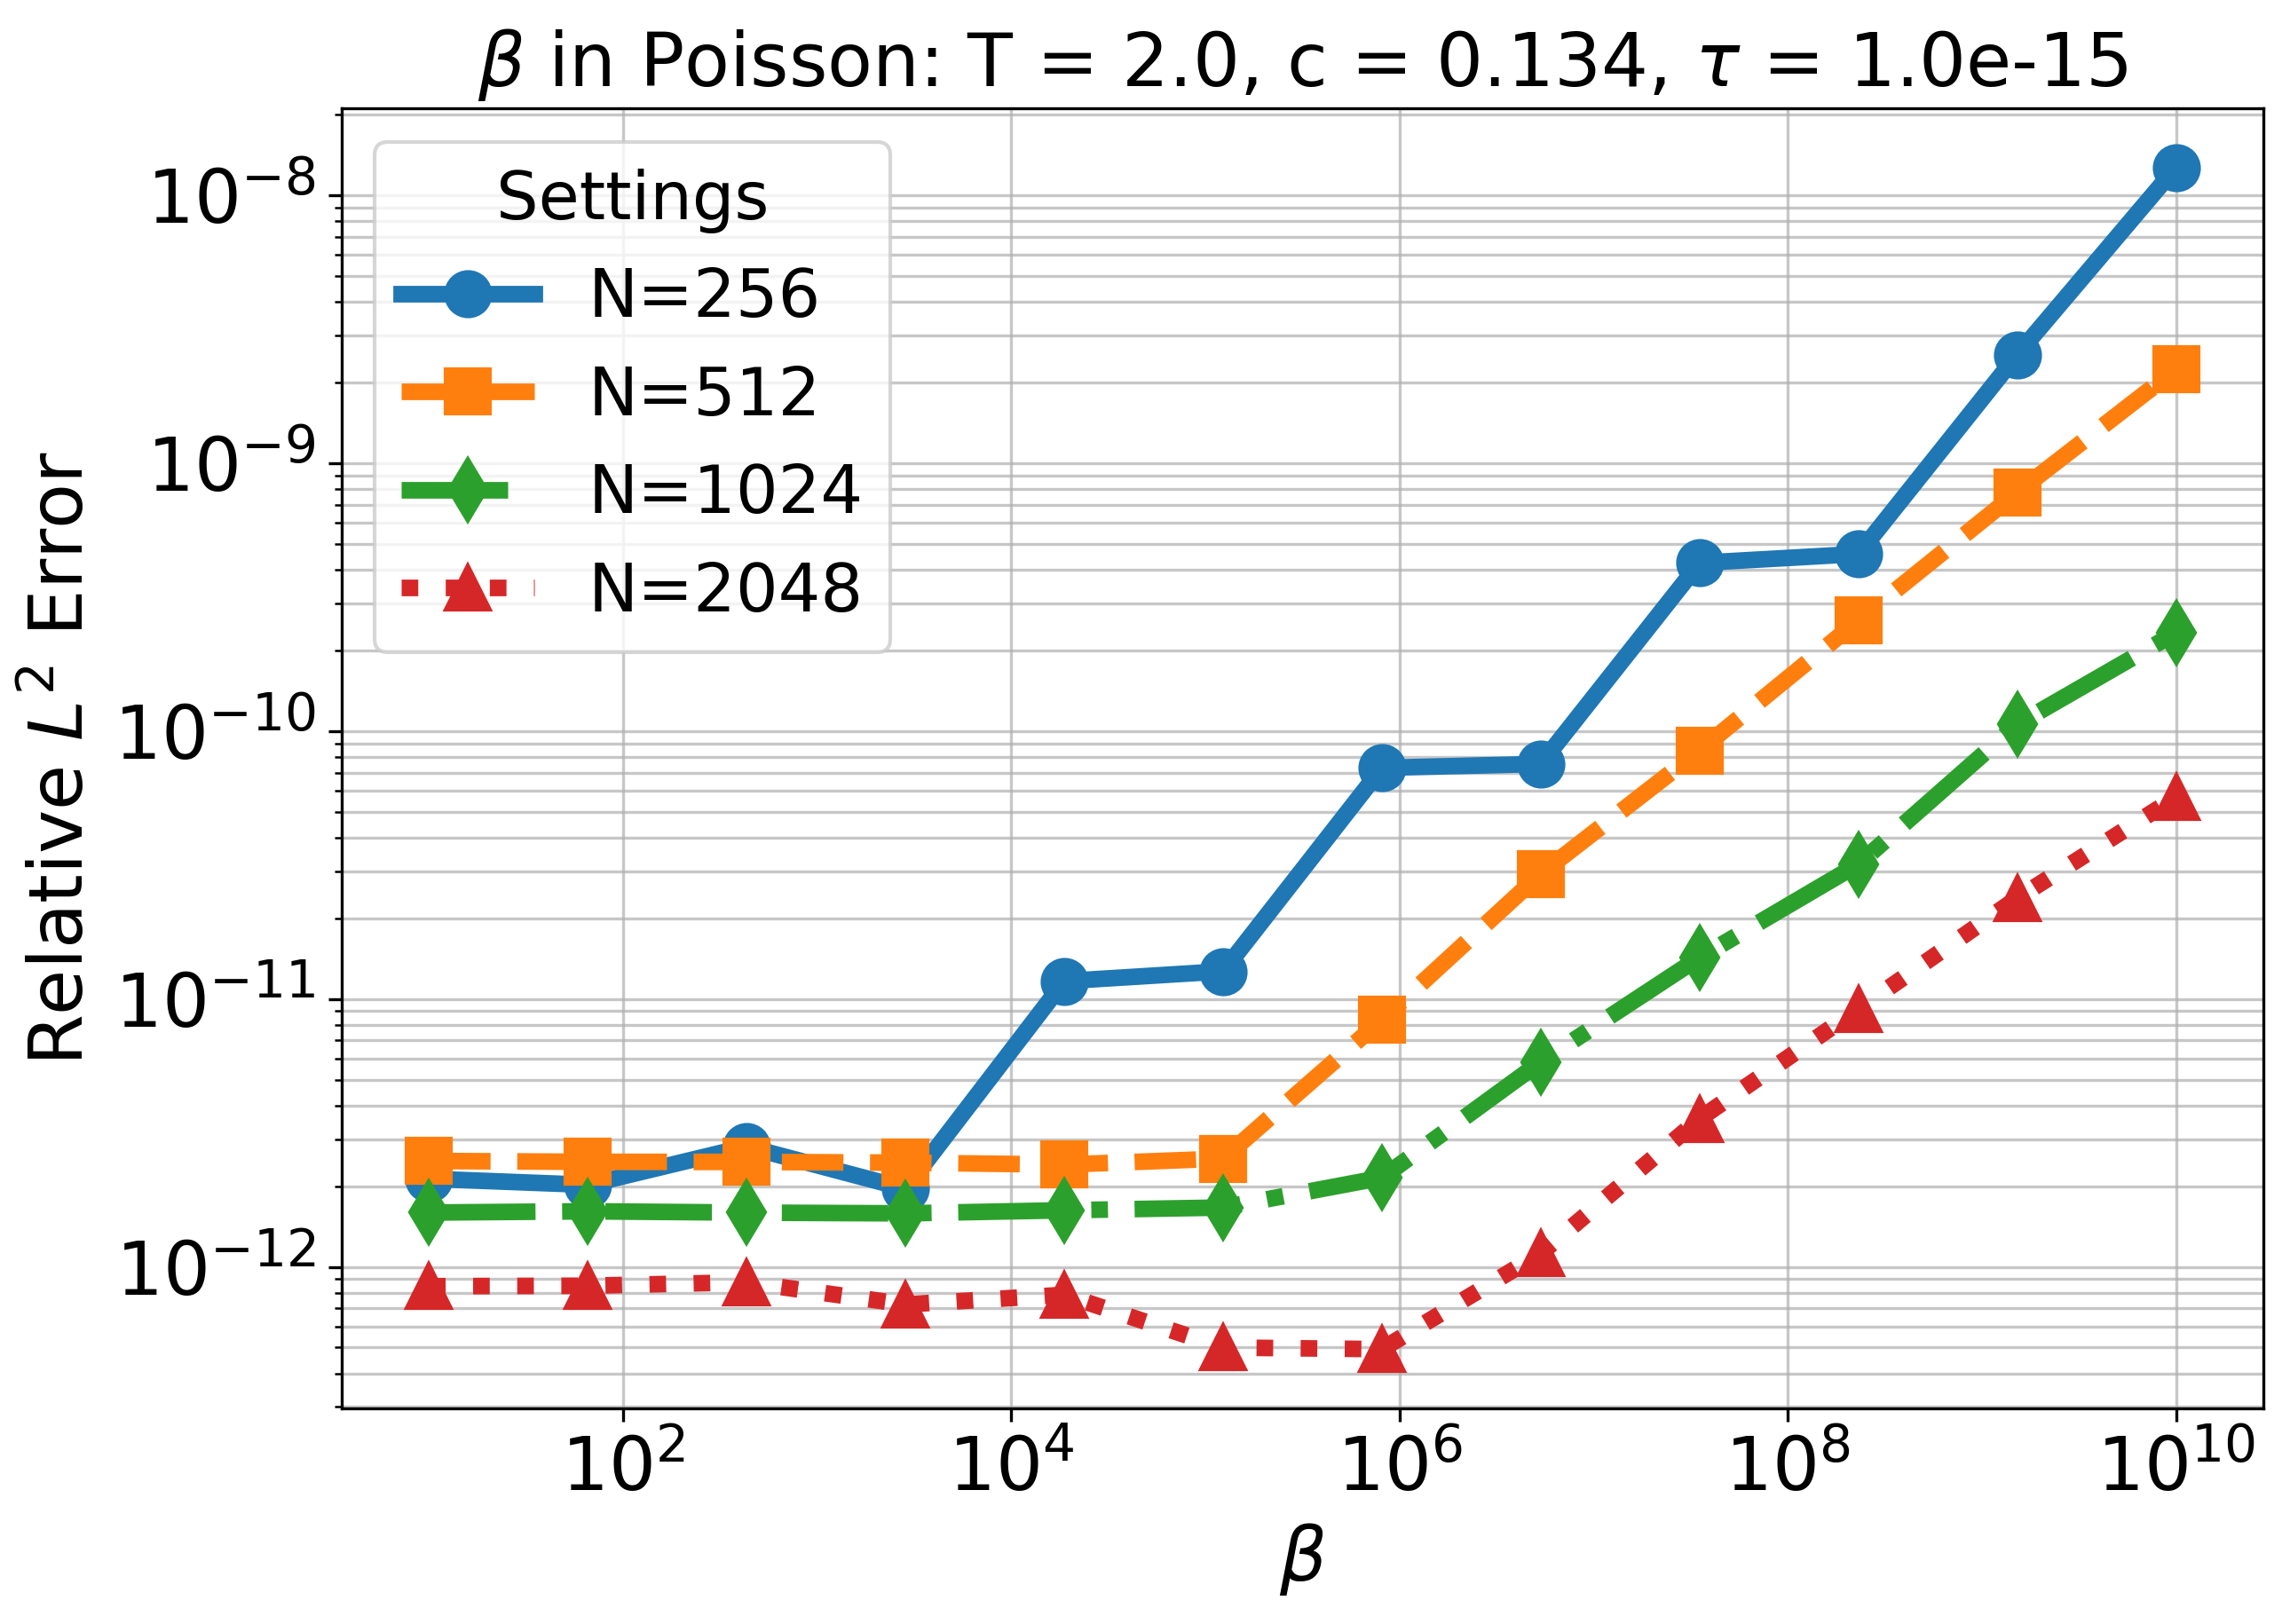

In [5]:
from itertools import cycle

# Assumes you already have:
# beta_values (1D array)
# errors_vs_beta = {N: [errs...]}  # same length as beta_values for each N
# If N_list not defined, infer it:
try:
    N_list
except NameError:
    N_list = sorted(errors_vs_beta.keys())



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})

# Ensure cycles
marker_cyc = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyle_cyc = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

for N in N_list:
    mk = next(marker_cyc)
    ls = next(linestyle_cyc)
    ax.loglog(beta_values, errors_vs_beta[N], linestyle=ls, marker=mk, label=f"N={N}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"$\beta$ in Poisson: T = {T}, c = {c_shape:.3f}, $\tau$ = {tau:.1e}")
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title="Settings", fontsize=18, title_fontsize = 18)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig13_poisson.png', dpi = 300)


# T = 4.0 

In [6]:
# ---- helper for c(T, tau)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# ---- settings
tau = 1e-15
T = 4.0
c_shape = float(c_from_T(T, tau))   # your code uses eps = c_shape * N
N_list = [256, 512, 1024, 2048]
beta_values = np.logspace(1, 10, num=12)  # 1e1 ... 1e10 (10 points)

# ---- storage: dict of {N: [errors vs beta]}
errors_vs_beta = {N: [] for N in N_list}

# ---- run sweep
for beta in beta_values:
    for N in N_list:
        rel_L2_sq = solver_rbf( N = N, rbf_func = rbf_gaussian, d2rbf_func = d2rbf_gaussian, tau=tau, beta=beta)
        errors_vs_beta[N].append(rel_L2_sq)

# ---- pretty print a table
header = ["beta"] + [f"N={N}" for N in N_list]
print("{:>12s}  ".format(header[0]) + "  ".join(f"{h:>12s}" for h in header[1:]))
for i, beta in enumerate(beta_values):
    row = [f"{beta:12.3e}"] + [f"{errors_vs_beta[N][i]:12.3e}" for N in N_list]
    print("  ".join(row))

        beta         N=256         N=512        N=1024        N=2048
   1.000e+01     2.132e-12     2.485e-12     1.595e-12     8.466e-13
   6.579e+01     2.023e-12     2.466e-12     1.612e-12     8.500e-13
   4.329e+02     2.810e-12     2.464e-12     1.594e-12     8.763e-13
   2.848e+03     1.958e-12     2.448e-12     1.584e-12     7.238e-13
   1.874e+04     1.166e-11     2.408e-12     1.626e-12     7.864e-13
   1.233e+05     1.268e-11     2.536e-12     1.665e-12     4.998e-13
   8.111e+05     7.290e-11     8.373e-12     2.152e-12     4.929e-13
   5.337e+06     7.538e-11     2.935e-11     5.821e-12     1.123e-12
   3.511e+07     4.245e-10     8.472e-11     1.428e-11     3.572e-12
   2.310e+08     4.582e-10     2.589e-10     3.185e-11     9.172e-12
   1.520e+09     2.540e-09     7.781e-10     1.060e-10     2.377e-11
   1.000e+10     1.272e-08     2.241e-09     2.327e-10     5.659e-11


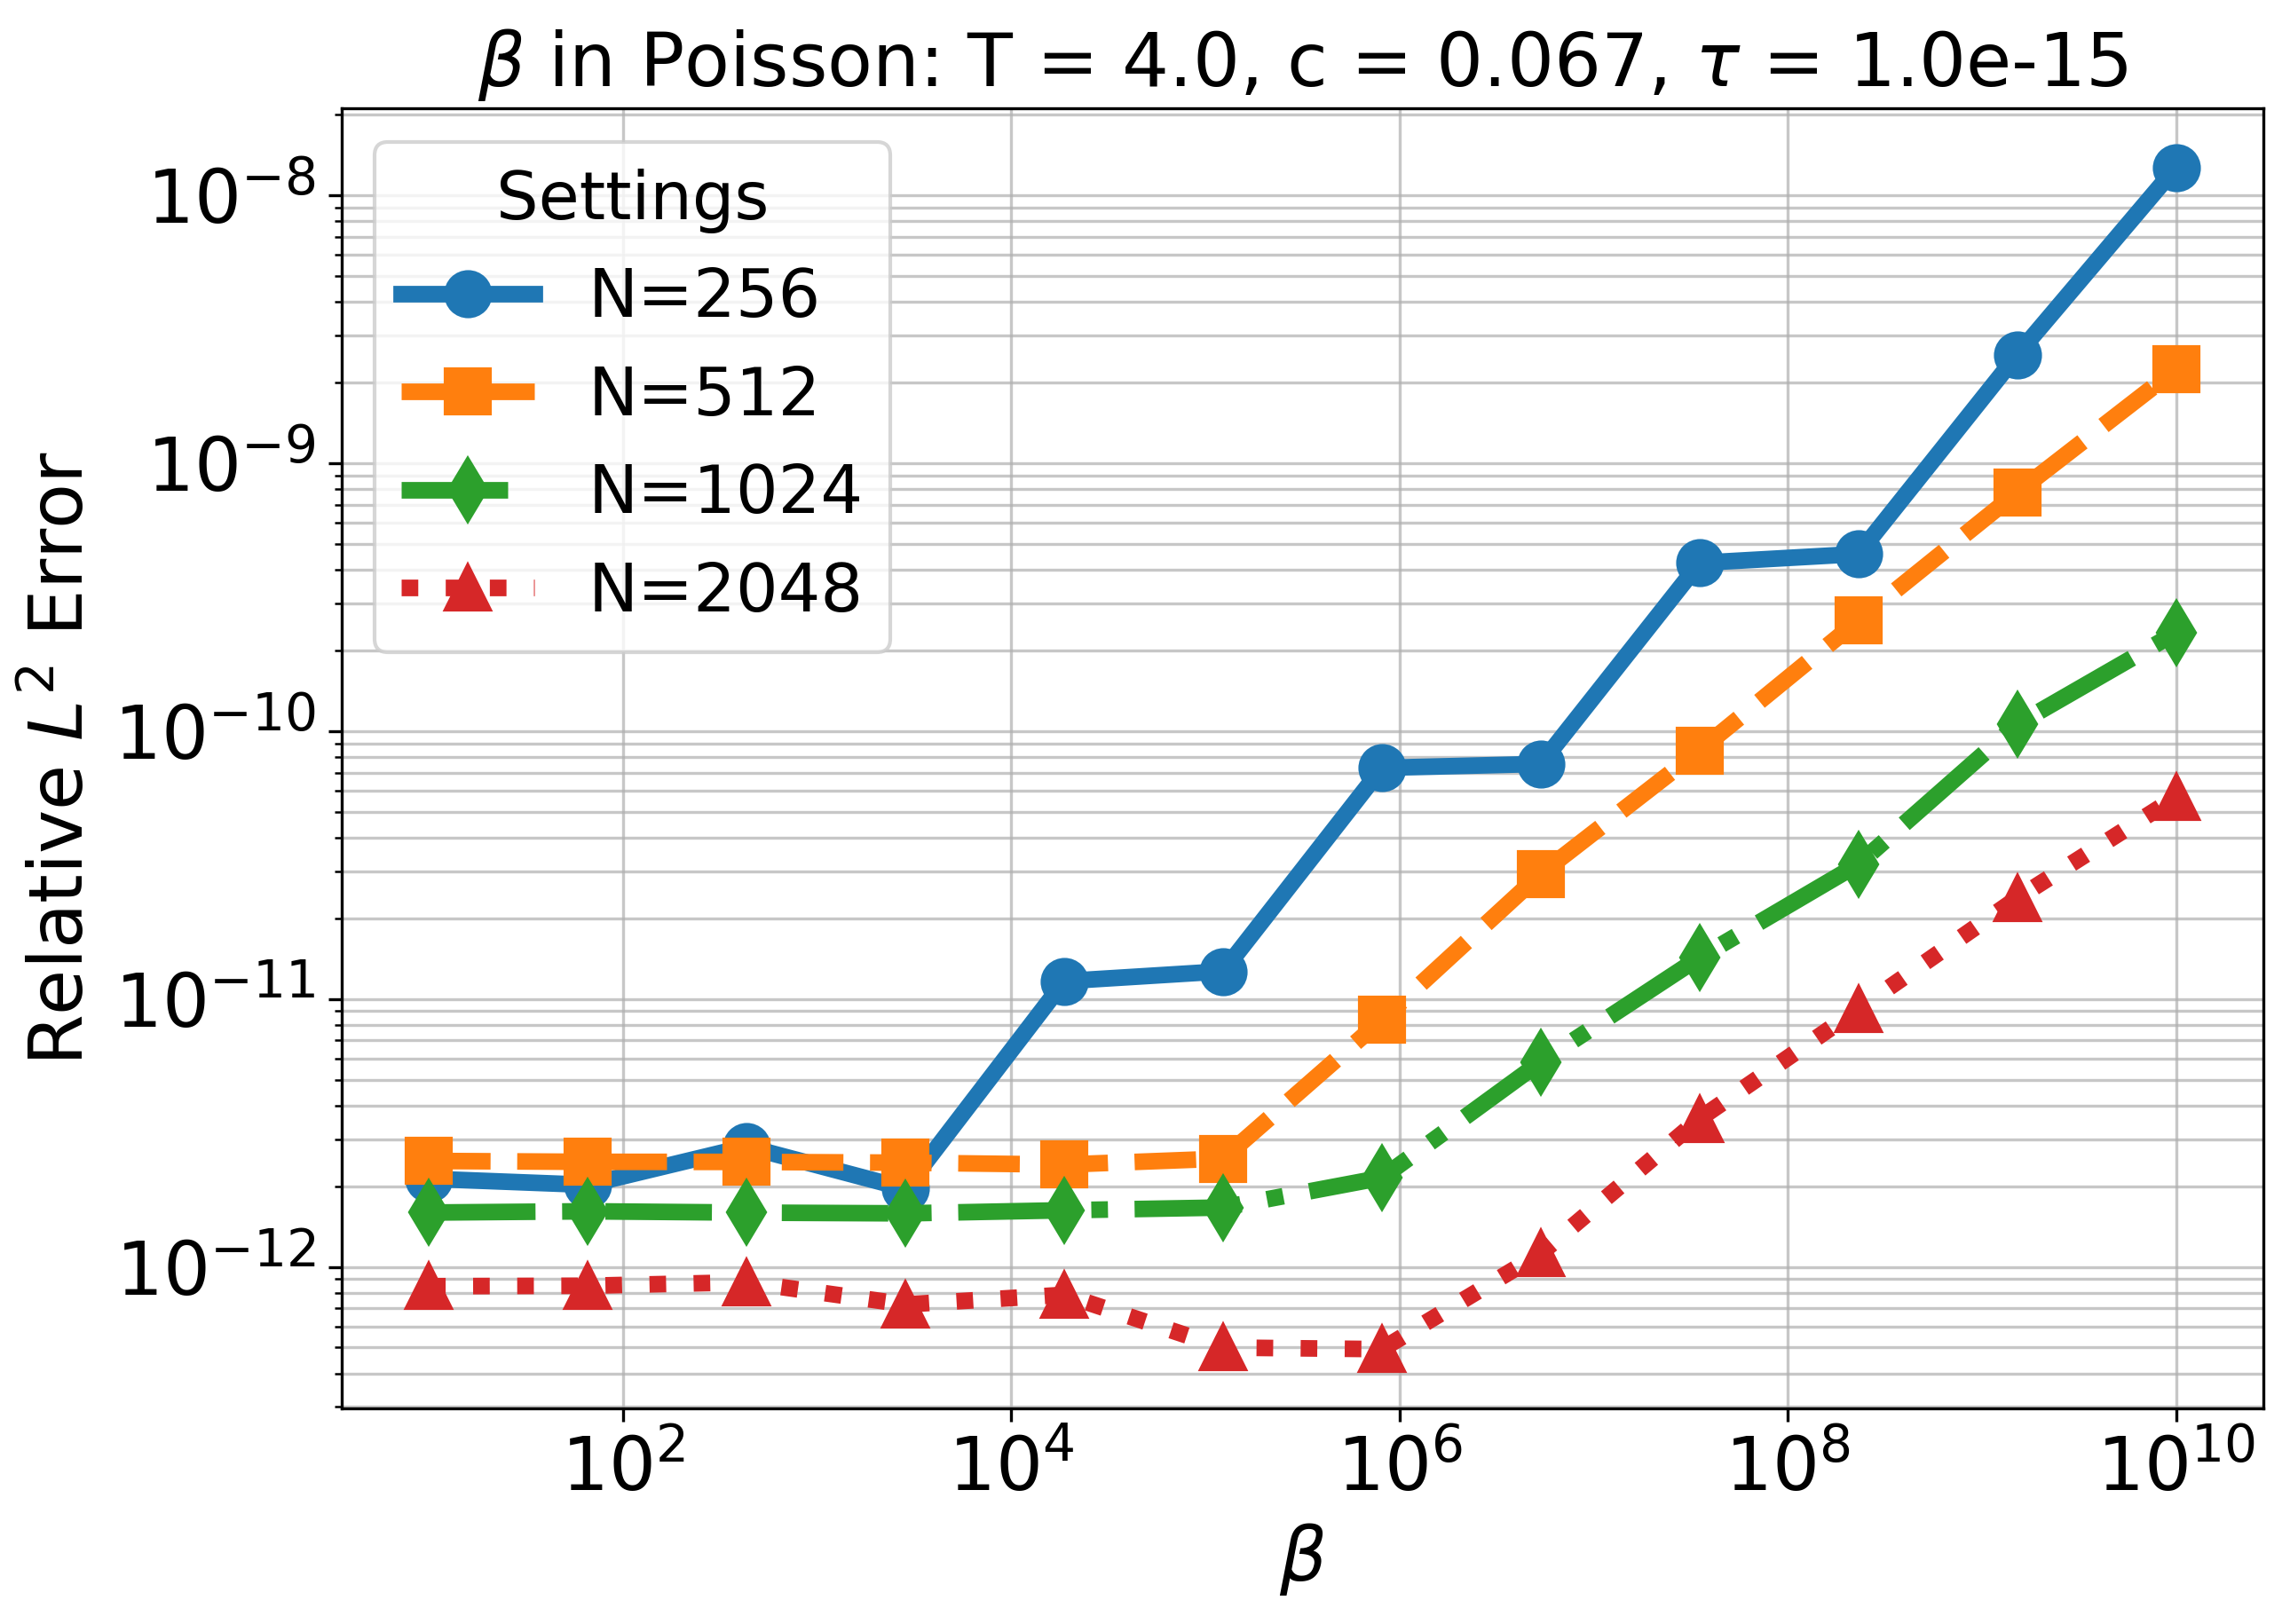

In [7]:
from itertools import cycle

# Assumes you already have:
# beta_values (1D array)
# errors_vs_beta = {N: [errs...]}  # same length as beta_values for each N
# If N_list not defined, infer it:
try:
    N_list
except NameError:
    N_list = sorted(errors_vs_beta.keys())



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})

# Ensure cycles
marker_cyc = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyle_cyc = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

for N in N_list:
    mk = next(marker_cyc)
    ls = next(linestyle_cyc)
    ax.loglog(beta_values, errors_vs_beta[N], linestyle=ls, marker=mk, label=f"N={N}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"$\beta$ in Poisson: T = {T}, c = {c_shape:.3f}, $\tau$ = {tau:.1e}")
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title="Settings", fontsize=18, title_fontsize = 18)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig14_poisson.png', dpi = 300)
